# 🧠 Практика 2: Как работает снятие alignment через refusal direction

**AI Threat Team**  

| **Алексей Самойленко** tg: @samoylenko23 | 

| **Владимир Беликов** tg: @james_white_116 | 

---

## Что разберём

https://github.com/p-e-w/heretic

1. почему отказ можно искать как **устойчивое направление** во внутренних состояниях модели;
2. зачем сравнивают **безопасные** и **опасные** запросы;
3. почему часто смотрят именно на **первый токен ответа**;
4. как из разности средних получается **refusal direction**;
5. зачем после этого используют **LoRA**;
6. почему правят не всю модель подряд, а только некоторые модули;


## Часть 1. Основная интуиция

Идея опирается на наблюдение из работы **Arditi et al., 2024**:

> отказное поведение модели может быть связано не с «магией по всей сети», а с **достаточно компактным паттерном** во внутреннем пространстве представлений.

То есть гипотеза такая:

- когда запрос безобиден, внутреннее состояние модели развивается в одном режиме;
- когда запрос опасен и модель готовится отказать, состояние смещается в другом направлении;
- если это смещение достаточно устойчиво, его можно **измерить**, **сравнить** и попытаться **ослабить**.


## Часть 2. Общая логика Heretic

Heretic (https://github.com/p-e-w/heretic) уже реализовал эту идею:

1. берём готовую модель;
2. подключаем LoRA-оболочку для будущей правки весов;
3. собираем внутренние состояния на двух типах запросов;
4. находим направление, связанное с отказом;
5. переводим эту правку в компактное обновление весов;
6. подбираем, **где** и **насколько сильно** вмешиваться, чтобы поведение изменилось, но модель не деградировала слишком сильно.

## Часть 3. Пошаговая логика метода

### Шаг 1. Базовая модель и LoRA

Изменение весов записывают в виде:

$$
W_{new} = W_{base} + \Delta W
$$

где добавка задаётся как произведение двух небольших матриц:

$$
\Delta W = BA
$$

Ключевой смысл такой:

- базовые веса не переписываются целиком;
- изменение хранится компактно;
- можно точечно внести правку и отдельно управлять её силой.



### Шаг 2. Два набора запросов

Дальше нужны две группы запросов:

- **harmless** — безопасные, обычные, нейтральные;
- **harmful** — такие, на которых модель обычно уходит в отказ.

Зачем это делается:

- безопасные запросы показывают режим **нормальной полезной помощи**;
- опасные запросы показывают режим **срабатывания защиты / отказа**.

Нам важно не просто посмотреть на ответы модели, а сравнить **её внутренние состояния** в этих двух режимах.


### Шаг 3. Берем первый токен

Для каждого промпта обычно генерируют только **первый токен ответа**, а затем снимают скрытые состояния по слоям.
  
Если смотреть позже, там уже смешиваются:

- собственно решение об отказе;
- стиль ответа;
- шаблонные фразы;
- форматирование и другие вторичные эффекты генерации.


### Шаг 4. Как получается refusal direction

На выбранном слое берём два набора векторов скрытых состояний:

- для безопасных запросов;
- для опасных запросов.

Считаем средние:

$$
\mu_{good}, \quad \mu_{bad}
$$

и строим разность:

$$
v = \mu_{bad} - \mu_{good}
$$

Часто затем вектор нормализуют:

$$
\hat v = \frac{v}{\|v\|}
$$


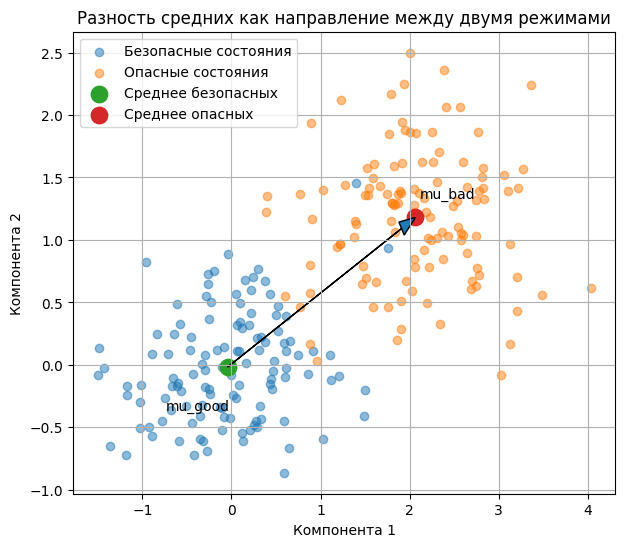

mu_good = [-0.04196928 -0.01703089]
mu_bad  = [2.06598651 1.18019712]
v       = [2.10795579 1.19722802]
Нормированный вектор = [0.86954055 0.49386155]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

good = rng.normal(loc=[0.0, 0.0], scale=[0.7, 0.5], size=(120, 2))
bad = rng.normal(loc=[2.0, 1.2], scale=[0.7, 0.5], size=(120, 2))

mu_good = good.mean(axis=0)
mu_bad = bad.mean(axis=0)
v = mu_bad - mu_good
v_unit = v / np.linalg.norm(v)

plt.figure(figsize=(7, 6))
plt.scatter(good[:, 0], good[:, 1], alpha=0.5, label='Безопасные состояния')
plt.scatter(bad[:, 0], bad[:, 1], alpha=0.5, label='Опасные состояния')

plt.scatter(*mu_good, s=140, label='Среднее безопасных')
plt.scatter(*mu_bad, s=140, label='Среднее опасных')

plt.arrow(
    mu_good[0], mu_good[1], v[0], v[1],
    length_includes_head=True,
    head_width=0.12
)

plt.annotate('mu_good', xy=mu_good, xytext=(mu_good[0]-0.7, mu_good[1]-0.35))
plt.annotate('mu_bad', xy=mu_bad, xytext=(mu_bad[0]+0.05, mu_bad[1]+0.15))

plt.title('Разность средних как направление между двумя режимами')
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.legend()
plt.grid(True)
plt.show()

print("mu_good =", mu_good)
print("mu_bad  =", mu_bad)
print("v       =", v)
print("Нормированный вектор =", v_unit)


## Часть 4. Что именно правим?

Часто это:

- **attention out-projection**;
- **MLP / FFN down-projection**.

### Почему именно они

Если отказ действительно выражен как направление в этом пространстве, то вмешательство в такие матрицы особенно эффективно, потому что мы влияем не на случайный фрагмент вычислений, а на то, **как блок в целом вносит вклад в общее состояние модели**.


## Часть 5. Как оценивают результат

Оценка почти всегда балансирует между двумя целями.

### 1. Изменить целевое поведение
Например, уменьшить частоту отказов на выбранном классе вредоносных запросов.

### 2. Не разрушить модель слишком сильно
Нужно проверить, насколько новая модель ушла от исходной на обычных задачах. Для этого часто смотрят на метрики вроде **KL-дивергенции** между распределениями токенов.


## Часть 6. Как выглядит общий pipeline

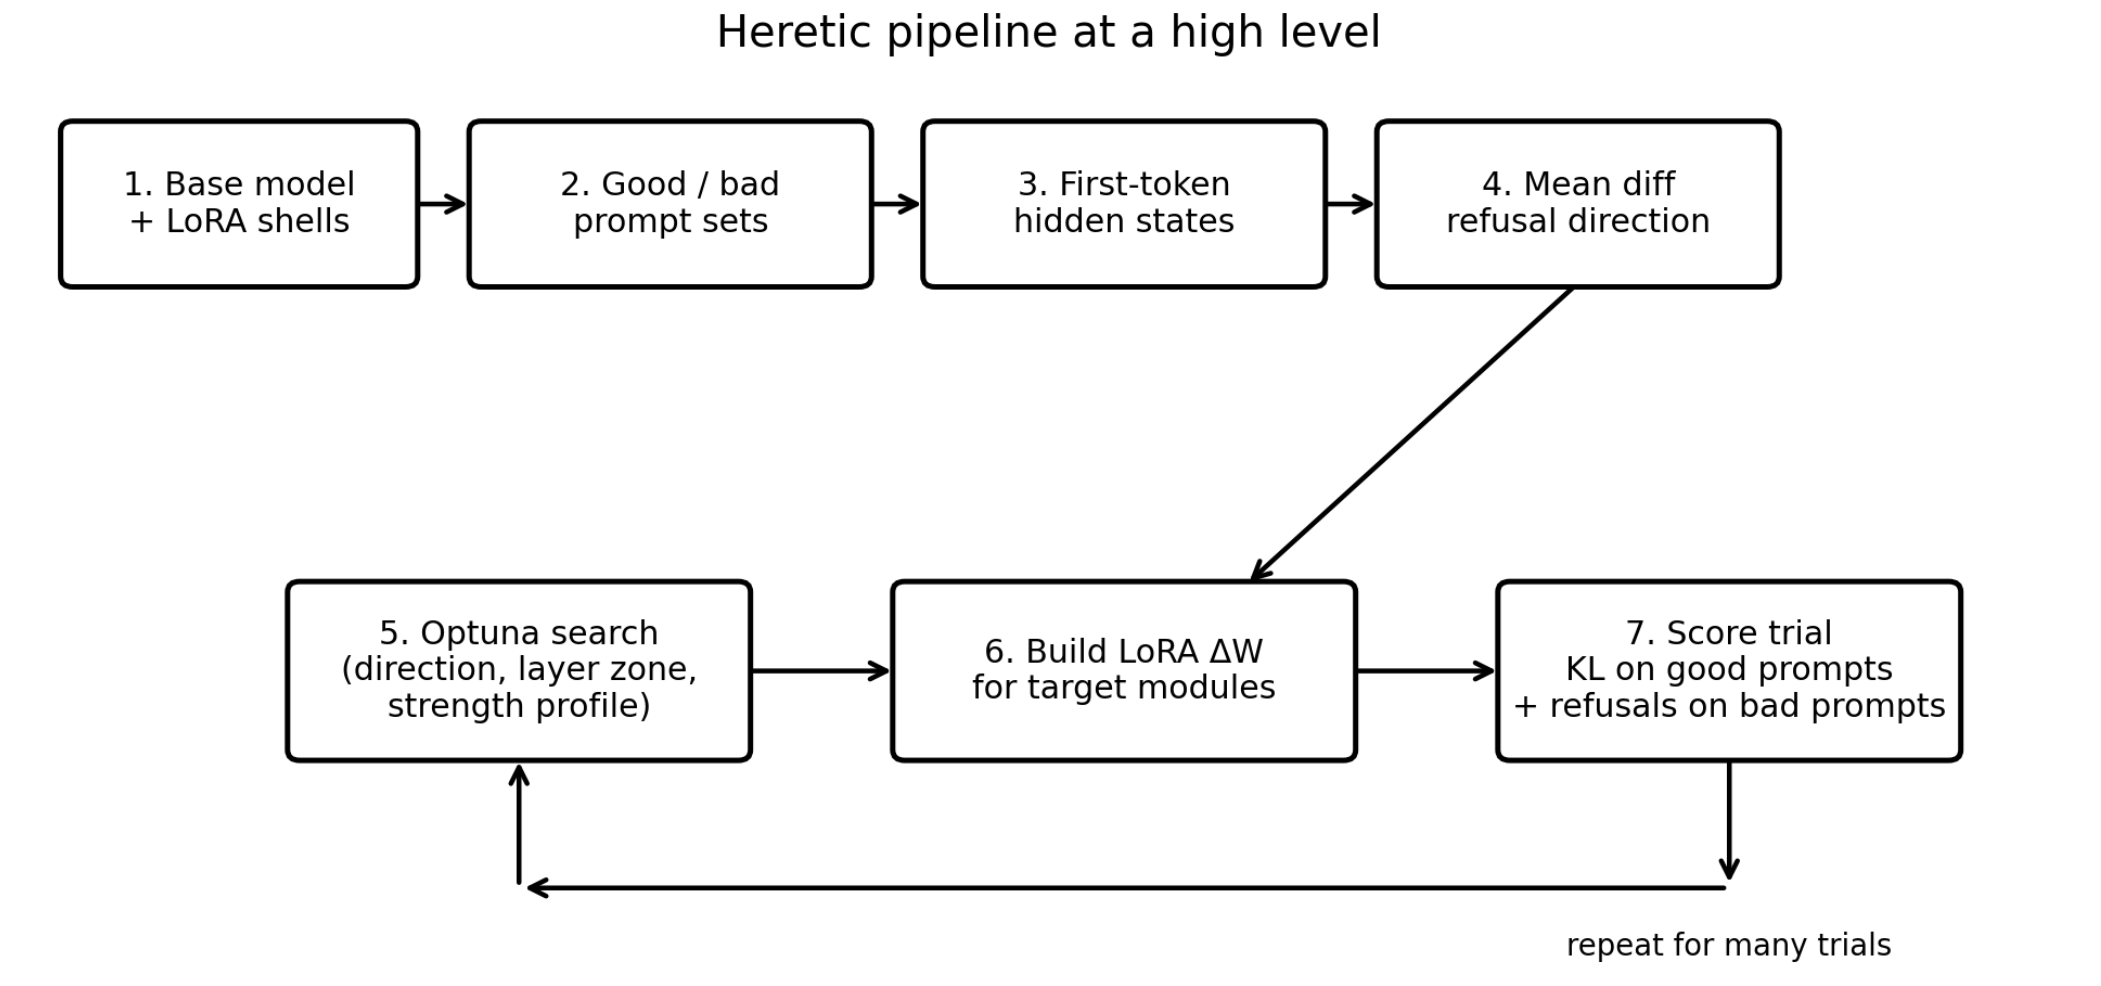


## Итог

В сжатом виде логика практики такая:

1. у модели есть как минимум два режима — обычная помощь и отказ;
2. эти режимы отражаются во внутренних состояниях;
3. различие между ними можно приблизить направлением в пространстве признаков;
4. это направление можно попытаться ослабить через компактную правку весов;
5. LoRA делает такую правку удобной и управляемой;
6. дальше вся сложность переходит в инженерный вопрос: **где**, **насколько сильно** и **с какой ценой** вмешиваться.